In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
from sklearn.datasets import load_diabetes


In [6]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes['data'])
y= diabetes['target']

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=10)

<Axes: >

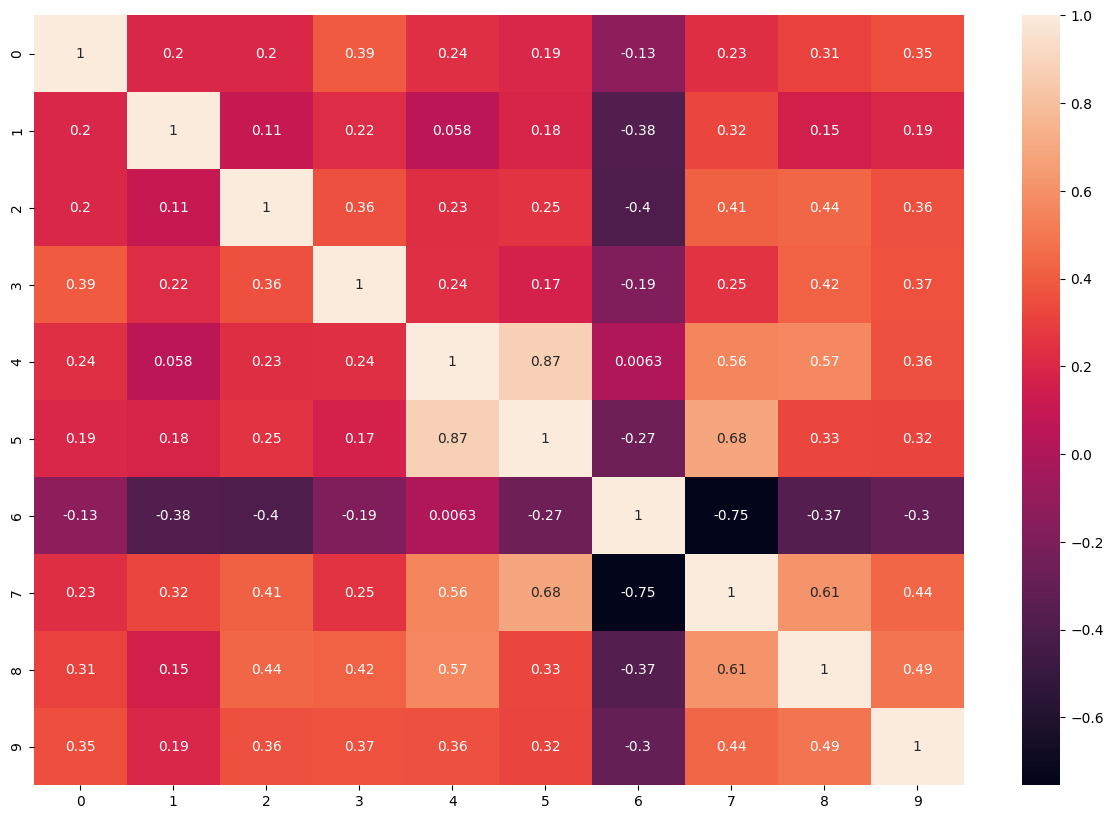

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [11]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}

    # max_features: Features considered for each split
    # - 'auto': Same as 'sqrt' for trees (√n_features random features)
    # - 'sqrt': ~√n_features random features per split
    # - 'log2': ~log₂(n_features) random features per split
    # None (not included) = all features
    
        # max_depth: Maximum tree depth
    # Controls overfitting - deeper = more complex, shallower = simpler
    # [1,2,3,4,5] = small trees | [10,15,20,25] = deeper trees
    
        # splitter: Strategy to choose split at each node
    # - 'best': Greedy approach - always picks best split (slower but more accurate)
    # - 'random': Faster - samples random splits, adds randomness
    
        # criterion: Function to measure split quality
    # - 'squared_error': MSE (default) - good for regression, penalizes large errors more
    # - 'friedman_mse': Modified MSE from Friedman - better for gradient boosting
    # - 'absolute_error': MAE - robust to outliers

In [14]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

grid=GridSearchCV(regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error')
grid.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'
